In [16]:
# plots for pres

# read in clean 24 data
import os
os.chdir("/Users/ellawileman/Downloads/clean_data")

In [17]:
import pandas as pd
dat = pd.read_csv("nov24pub_clean.csv")

In [23]:
dat["PES4"].value_counts()

PES4
-1     56928
 4      1058
 5       946
 7       793
 1       770
 11      631
 2       397
 3       228
 8       208
 6       143
 10      125
-2       123
-3        45
 9        14
Name: count, dtype: int64

In [35]:
# only people who didnt note 
no_vote = dat[dat["PES4"] != -1]


In [39]:
# filter people who didnt vote


In [45]:
no_vote.loc[no_vote['PES4'] == 4, 'why_didnt_vote'] = 'Thought vote would not matter'
no_vote.loc[no_vote['PES4'] == 7, 'why_didnt_vote'] = 'Do not like candidates or campaigns'
no_vote.loc[(no_vote['PES4'] != 4) & (no_vote['PES4'] != 7), 'why_didnt_vote'] = 'Other'



In [ ]:
def group_reason(x):
    if x == 4:
        return "Felt vote would not matter"
    elif x == 7:
        return "Candidate dissatisfaction"
    elif x in [5, 10]:
        return "Time/inconvenience"
    elif x in [1, 6]:
        return "Health/transport"
    elif x in [2, 3]:
        return "Logistics/forgot"
    elif x == 8:
        return "Registration issues"
    else:
        return "Other"

no_vote["why_didnt_vote"] = no_vote["PES4"].apply(group_reason)



In [53]:
def group_reason(x):
    if x == 4:
        return "Felt vote would not matter"
    else:
        return "Other"

no_vote["why_didnt_vote"] = no_vote["PES4"].apply(group_reason)



/var/folders/yz/btvl331d4g54624wdzgx_2hc0000gn/T/ipykernel_9978/1019914282.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  no_vote["why_didnt_vote"] = no_vote["PES4"].apply(group_reason)


In [54]:
counts = no_vote.groupby('why_didnt_vote')['PWSSWGT'].sum()


In [55]:
counts

why_didnt_vote
Felt vote would not matter     35833461594
Other                         145778287883
Name: PWSSWGT, dtype: int64

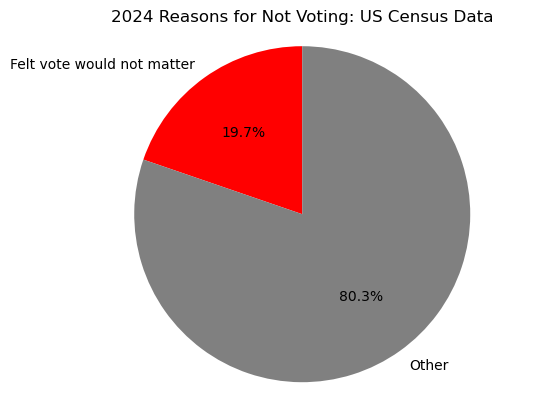

In [60]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

plt.figure()
plt.pie(counts, labels=counts.index, colors=['red', 'grey'], autopct='%1.1f%%', startangle=90)
plt.title('2024 Reasons for Not Voting: US Census Data')
plt.axis('equal')
plt.xticks(rotation=30, ha='right')

plt.show()

In [3]:
epochs = [1,2,3,4,5,6,7,8,9]
val_loss = [0.0714,0.0627,0.0717,0.0584,0.0596,0.0663,0.0648,0.0654,0.0760]

Text(0, 0.5, 'Validation Loss')

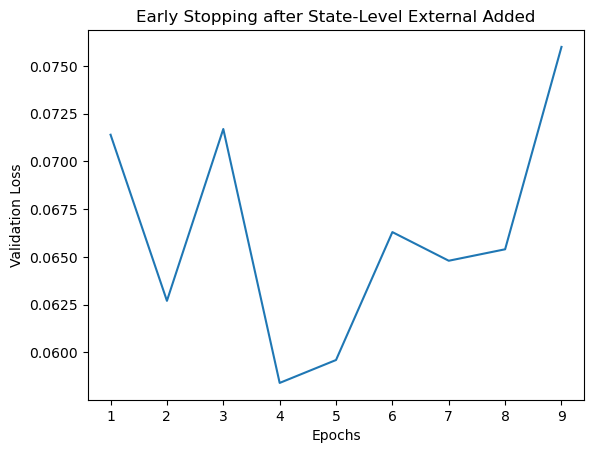

In [5]:
import matplotlib.pyplot as plt
plt.plot(epochs,val_loss)
plt.title('Early Stopping after State-Level External Added')
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")